# Phase 1.1 — NASS Yield Data Ingestion

Fetch county-level corn yield history (2005–2024) for all 5 target states from the USDA NASS QuickStats API and cache the results to S3.

**States**: Iowa (IA), Colorado (CO), Wisconsin (WI), Missouri (MO), Nebraska (NE)  
**Metric**: CORN, GRAIN — YIELD, MEASURED IN BU/ACRE


In [11]:
import os, requests
r = requests.get(
    "https://quickstats.nass.usda.gov/api/api_GET/",
    params={
        "key": os.environ["NASS_API_KEY"],
        "source_desc": "SURVEY", "sector_desc": "CROPS",
        "commodity_desc": "CORN", "statisticcat_desc": "YIELD",
        "unit_desc": "BU / ACRE", "agg_level_desc": "COUNTY",
        "state_fips_code": "19", "year": 2023, "format": "JSON",
    },
    timeout=30,
)
print("HTTP:", r.status_code)
print(r.text[:400])

HTTP: 200
{"data":[{"year":2023,"county_name":"BUENA VISTA","group_desc":"FIELD CROPS","asd_code":"10","location_desc":"IOWA, NORTHWEST, BUENA VISTA","statisticcat_desc":"YIELD","domaincat_desc":"NOT SPECIFIED","zip_5":"","sector_desc":"CROPS","Value":"212","state_fips_code":"19","week_ending":"","country_code":"9000","region_desc":"","watershed_desc":"","asd_desc":"NORTHWEST","unit_desc":"BU / ACRE","count


In [12]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
# If running from notebooks/ directory:
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

from data_utils import fetch_all_states, load_all_states, STATES

BUCKET = "cornsight-data"


## Step 1 — Fetch from NASS API and cache to S3

Run this once. After the CSVs are in S3, use `load_all_states()` instead to avoid re-hitting the API.


In [13]:
import os
from dotenv import load_dotenv, find_dotenv

# Explicitly load .env from the project root (works regardless of kernel cwd)
load_dotenv(find_dotenv(usecwd=False), override=True)

if os.environ.get("NASS_API_KEY"):
    print("NASS_API_KEY is set.")
else:
    print("WARNING: NASS_API_KEY is not set. Check your .env file.")


NASS_API_KEY is set.


In [14]:
# NOTE: Set your NASS API key before running
# Either: os.environ["NASS_API_KEY"] = "your_key_here"
# Or set it in your shell: $env:NASS_API_KEY = "your_key"

yields_df = fetch_all_states(BUCKET, year_start=2005, year_end=2024)
print(f"\nTotal rows fetched: {len(yields_df)}")
print(yields_df["state"].value_counts())


Fetching IA (FIPS 19)...
    year 2005... 99 rows
    year 2006... 99 rows
    year 2007... 99 rows
    year 2008... 99 rows
    year 2009... 99 rows
    year 2010... 99 rows
    year 2011... 99 rows
    year 2012... 99 rows
    year 2013... 99 rows
    year 2014... 99 rows
    year 2015... 97 rows
    year 2016... 99 rows
    year 2017... 96 rows
    year 2018... 96 rows
    year 2019... 92 rows
    year 2020... 96 rows
    year 2021... 85 rows
    year 2022... 98 rows
    year 2023... 88 rows
    year 2024... 74 rows
  1911 rows saved to s3://cornsight-data/processed/yields/state_19.csv
Fetching CO (FIPS 08)...
    year 2005... 69 rows
    year 2006... 66 rows
    year 2007... 65 rows
    year 2008... 39 rows
    year 2009... 7 rows
    year 2010... 48 rows
    year 2011... 37 rows
    year 2012... 31 rows
    year 2013... 23 rows
    year 2014... 23 rows
    year 2015... 28 rows
    year 2016... 42 rows
    year 2017... 25 rows
    year 2018... 25 rows
    year 2019... 16 rows
    y

## Step 2 — Reload from S3 (skip the API on subsequent runs)


In [15]:
yields_df = load_all_states(BUCKET)
print(f"Loaded {len(yields_df)} rows from S3")
yields_df.head()


Loaded 9014 rows from S3


,year,county_name,yield_bu_acre,state,state_fips
0,2005,BUENA VISTA,185.3,IA,19
1,2005,CHEROKEE,185.5,IA,19
2,2005,CLAY,183.1,IA,19
3,2005,DICKINSON,170.4,IA,19
4,2005,EMMET,182.7,IA,19


## Step 3 — Quick sanity checks


Year range per state:
        min   max  count
state                   
CO     2005  2024    637
IA     2005  2024   1911
MO     2005  2024   1567
NE     2005  2024   3632
WI     2005  2024   1267

Missing yield values: 0 / 9014


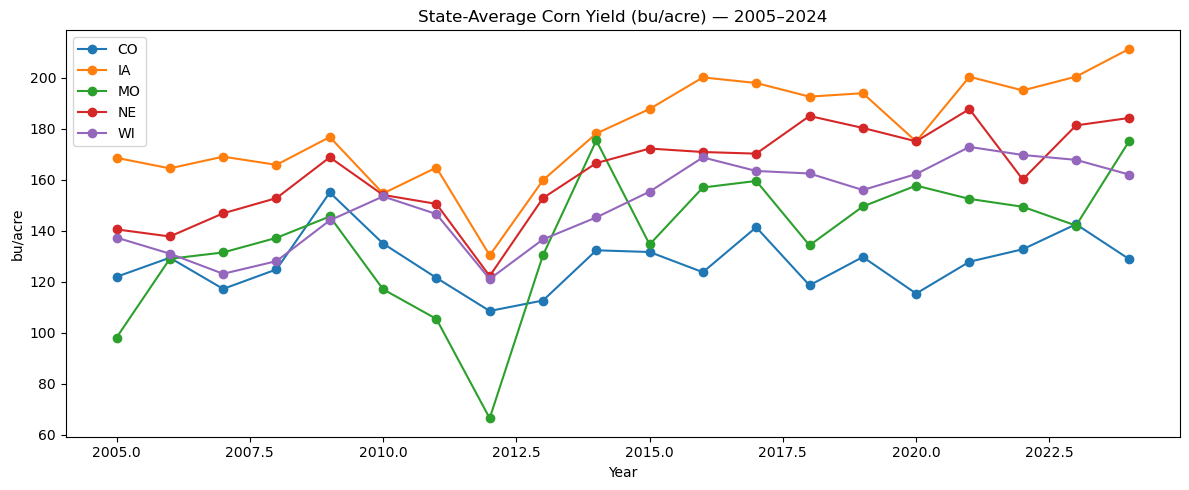

In [16]:
import matplotlib.pyplot as plt

# Check year coverage per state
print("Year range per state:")
print(yields_df.groupby("state")["year"].agg(["min", "max", "count"]))

# Check for missing yield values
missing = yields_df["yield_bu_acre"].isna().sum()
print(f"\nMissing yield values: {missing} / {len(yields_df)}")

# State-level average yield over time
state_avg = (
    yields_df.groupby(["state", "year"])["yield_bu_acre"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for state, grp in state_avg.groupby("state"):
    ax.plot(grp["year"].astype(int), grp["yield_bu_acre"], marker="o", label=state)
ax.set_title("State-Average Corn Yield (bu/acre) — 2005–2024")
ax.set_xlabel("Year")
ax.set_ylabel("bu/acre")
ax.legend()
plt.tight_layout()
plt.show()


# Phase 1.2 — Cropland Data Layer (CDL)

Download CDL GeoTIFFs from USDA NASS CropScape for each state (2005–2024), mask to corn pixels only (class 1), and cache to S3.

`fetch_all_cdl()` automatically skips files already in S3, so it's safe to re-run if interrupted.


In [17]:
from data_utils import fetch_all_cdl, load_cdl_from_s3, STATES

# Download CDL for all 5 states, 2005–2024, and cache to S3
# This will take a while — each state/year is ~50–200MB before masking
fetch_all_cdl(BUCKET, year_start=2005, year_end=2024)


  Skipping IA 2005 (already in S3)
  Skipping IA 2006 (already in S3)
  Skipping IA 2007 (already in S3)
  Skipping IA 2008 (already in S3)
  Skipping IA 2009 (already in S3)
  Skipping IA 2010 (already in S3)
  Skipping IA 2011 (already in S3)
  Skipping IA 2012 (already in S3)
  Skipping IA 2013 (already in S3)
  Skipping IA 2014 (already in S3)
  Skipping IA 2015 (already in S3)
  Skipping IA 2016 (already in S3)
  Skipping IA 2017 (already in S3)
  Skipping IA 2018 (already in S3)
  Skipping IA 2019 (already in S3)
  Skipping IA 2020 (already in S3)


  Skipping IA 2021 (already in S3)
  Skipping IA 2022 (already in S3)
  Skipping IA 2023 (already in S3)
  Skipping IA 2024 (already in S3)
  Fetching CDL URL for FIPS 08, 2005...
  ERROR CO 2005: 500 Server Error: Internal Server Error for url: https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile?year=2005&fips=08
  Fetching CDL URL for FIPS 08, 2006...
  ERROR CO 2006: 500 Server Error: Internal Server Error for url: https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile?year=2006&fips=08
  Fetching CDL URL for FIPS 08, 2007...
  ERROR CO 2007: 500 Server Error: Internal Server Error for url: https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile?year=2007&fips=08
  Skipping CO 2008 (already in S3)
  Skipping CO 2009 (already in S3)
  Skipping CO 2010 (already in S3)
  Skipping CO 2011 (already in S3)
  Skipping CO 2012 (already in S3)
  Skipping CO 2013 (already in S3)
  Skipping CO 2014 (already in S3)
  Skipping CO 2015 (already in S3)
  Skipping CO

Array shape : (11671, 17795)
CRS         : EPSG:5070
Resolution  : 30.0 m
Corn pixels : 57,594,074
Corn area   : 51834.7 km²


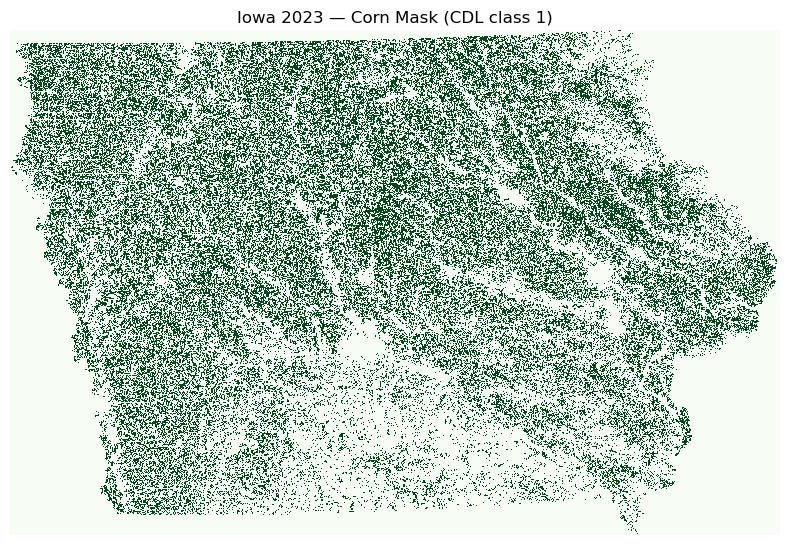

In [18]:
# Sanity check — load one state/year and confirm corn pixel count
corn_mask, profile = load_cdl_from_s3(BUCKET, state_fips="19", year=2023)  # Iowa 2023

print(f"Array shape : {corn_mask.shape}")
print(f"CRS         : {profile['crs']}")
print(f"Resolution  : {profile['transform'].a:.1f} m")
print(f"Corn pixels : {corn_mask.sum():,}")
print(f"Corn area   : {corn_mask.sum() * 30 * 30 / 1e6:.1f} km²")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(corn_mask, cmap="Greens", interpolation="none")
ax.set_title("Iowa 2023 — Corn Mask (CDL class 1)")
ax.axis("off")
plt.tight_layout()
plt.show()


# Phase 1.3 — HLS Multispectral Imagery

Download Harmonized Landsat Sentinel-2 (HLS) tiles from NASA EarthData for the corn growing season. These 6-band images are the direct input to Prithvi-100M.

**Required env vars** (set before running):
```
EARTHDATA_USERNAME=your_username
EARTHDATA_PASSWORD=your_password
```
Register free at https://urs.earthdata.nasa.gov/

**No download or S3 upload needed** — granules are streamed directly from NASA's S3 via `iter_granules_cloud()`. Only the extracted Prithvi feature vectors get written to your S3 bucket.

**Hackathon tip**: Use `max_granules=5` when testing to stream just a few tiles before running the full state/year.


In [19]:
import sys
sys.path.insert(0, "../src")
from hls_downloader import login, iter_granules_cloud

login()

# Stream 5 granules for Iowa 2023 directly from NASA S3 — no download needed
for stacked, profile, gid in iter_granules_cloud("IA", 2023, "final", max_granules=5):
    print(f"  {gid}  shape={stacked.shape}  crs={profile['crs']}")
    for i, band in enumerate(["B02","B03","B04","B05","B06","B07"]):
        print(f"    {band}: min={stacked[i].min():.4f}  max={stacked[i].max():.4f}  mean={stacked[i].mean():.4f}")
    print()


EarthData login successful.


/home/ec2-user/miniconda3/envs/Hackathon2026/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


  Found 4251 granules for IA 2023 [final]


/home/ec2-user/miniconda3/envs/Hackathon2026/lib/python3.11/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

...

  HLS.L30.T15TYG.2023121T164646.v2.0  shape=(6, 3660, 3660)  crs=EPSG:32615
    B02: min=-9999.0000  max=10013.0000  mean=-6813.0195
    B03: min=-9999.0000  max=9882.0000  mean=-6679.4326
    B04: min=-9999.0000  max=10293.0000  mean=-6624.3774
    B05: min=-9999.0000  max=10364.0000  mean=-6257.5391
    B06: min=-9999.0000  max=11175.0000  mean=-6556.6826
    B07: min=-9999.0000  max=11943.0000  mean=-6645.4751



QUEUEING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/15 [00:00<?, ?it/s]

  HLS.L30.T15TYH.2023121T164646.v2.0  shape=(6, 3660, 3660)  crs=EPSG:32615
    B02: min=-9999.0000  max=9603.0000  mean=-3995.0010
    B03: min=-9999.0000  max=9413.0000  mean=-3837.2163
    B04: min=-9999.0000  max=9651.0000  mean=-3775.4812
    B05: min=-9999.0000  max=9773.0000  mean=-3185.9221
    B06: min=-9999.0000  max=9909.0000  mean=-3988.1331
    B07: min=-9999.0000  max=8845.0000  mean=-4123.9053



In [20]:
# Quick search count — confirms auth and bbox coverage before streaming
from hls_downloader import search_hls

for state in ["IA", "CO", "WI", "MO", "NE"]:
    results = search_hls(state, 2023, "final")
    print(f"{state} 2023 [final]: {len(results)} granules available")


  Found 4251 granules for IA 2023 [final]
IA 2023 [final]: 4251 granules available
  Found 6051 granules for CO 2023 [final]
CO 2023 [final]: 6051 granules available
  Found 4492 granules for WI 2023 [final]
WI 2023 [final]: 4492 granules available
  Found 6473 granules for MO 2023 [final]
MO 2023 [final]: 6473 granules available
  Found 4616 granules for NE 2023 [final]
NE 2023 [final]: 4616 granules available
